## Introduction to Neural Network Classification with TensorFlow

In this notebook we're going to learn how to write neural networks for classification problems.

A classification problem is where you tryto classify something as one thing or another.

* Binary Classification
* Multiclass Classification
* Multilabel Classification



## Creating data to view and fit

In [ ]:
from sklearn.datasets import make_circles

# make 1000 examples

n_samples = 1000

# create circles
x,y = make_circles(n_samples,
                   noise=0.03,
                   random_state=42)

In [ ]:
# check-out features
x[:10]

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       [-0.39373073,  0.69288277],
       [ 0.44220765, -0.89672343],
       [-0.47964637,  0.67643477],
       [-0.01364836,  0.80334872],
       [ 0.77151327,  0.14775959],
       [-0.16932234, -0.79345575],
       [-0.1214858 ,  1.02150905]])

In [ ]:
# check the labels
y[:10]

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0])

## Our data is little to hard to understand right now let's visualize it!

In [ ]:
# visualize the data
import pandas as pd

circles = pd.DataFrame({"X0":x[:,0], "X1":x[:,1], "label":y})
circles

,X0,X1,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
...,...,...,...
995,0.244054,0.944125,0
996,-0.978655,-0.272373,0
997,-0.136900,-0.810012,1
998,0.670362,-0.767502,0


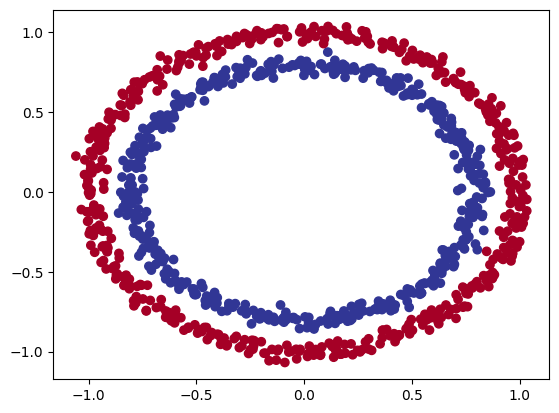

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(x[:,0] , x[:,1] , c=y , cmap=plt.cm.RdYlBu)

## Input and Output Shapes

In [ ]:
# check the shapes of our features and labels

x.shape, y.shape

((1000, 2), (1000,))

In [ ]:
# how many samples we're working
len(x),len(y)

(1000, 1000)

In [ ]:
# view the first example of features and labels
x[0],y[0]

(array([0.75424625, 0.23148074]), np.int64(1))

## Steps of the modelling

The steps in Modelling with TensorFlow are Tipically:

1. create or import a model
2. compile the model
3. fit the model
4. Evaluate the model
5. Tweaking
6. Evaluate



In [ ]:
import tensorflow as tf

# 1. Set TensorFlow seed
tf.random.set_seed(42)

# creating model
model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(5),
    tf.keras.layers.Dense(1)


])

# compile the model
model_1.compile(loss=tf.keras.losses.BinaryCrossentropy,
                optimizer=tf.keras.optimizers.SGD(),
                metrics=['accuracy'])

# fit the model
model_1.fit(x,y,epochs=100)



Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4720 - loss: 3.9257
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4970 - loss: 0.7286
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4850 - loss: 0.7004
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4710 - loss: 0.6973
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4590 - loss: 0.6968
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4600 - loss: 0.6967
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4590 - loss: 0.6966
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4600 - loss: 0.6966
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4580 - loss: 0.6966
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4580 - loss: 0.6966
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4570 - loss: 0.6966
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accurac

KeyboardInterrupt: 

In [ ]:
model_1.evaluate(x,y)

## Since we're working on a binary clasification problem and our model is getting around 50%  accuracy... it's performing as if it's guessing

So let's step things up a notch and add an extra layer

In [ ]:
# 1. Set TensorFlow seed
tf.random.set_seed(42)

# creating model
model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(1),
    tf.keras.layers.Dense(1)


])

# compile the model
model_2.compile(loss=tf.keras.losses.BinaryCrossentropy,
                optimizer=tf.keras.optimizers.SGD(),
                metrics=['accuracy'])

# fit the model
model_2.fit(x,y,epochs=100,verbose=0)



In [ ]:
model_2.evaluate(x,y)

In [ ]:
circles['label'].value_counts()

## Improving our model

Let's look into  our bag of tricks to see how we can improve our model

1. Create a model - we might add more layers or increase the number of hidden unit within a layer.

2. compiling a model - here we might to choose a different optimization function such as Adam instead of SGD.
3. fitting a model - perhaps we might fit our model for more epochs (leave it training for longer).

In [ ]:
# set the random seed
tf.random.set_seed(42)

# creating a model ( this time more layers)
model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(50),
    tf.keras.layers.Dense(1)
])

# compile the model
model_3.compile(loss=tf.keras.losses.BinaryCrossentropy(), # Use as a function
                optimizer=tf.keras.optimizers.SGD(), # Changed optimizer to Adam for potentially better performance
                metrics=['accuracy'])

# fit the model
model_3.fit(x,y,epochs=100, verbose=2) # Set verbose to 0 to suppress epoch output during modification

In [ ]:
print('Evaluating model_3 after adding layers and changing optimizer:')
loss, accuracy = model_3.evaluate(x,y)
print(f"New accuracy of model_3: {accuracy*100:.2f}%")

## To vizualise our model's predictions let's create a function `plot_decisions_boundry()` this function will >

* take in a trained model, features (x) and (y) labels
* create a meshfrid of a different x values
*  make prediction across the meshgrid
* plot the predictions as well as a line between zones (where each unique class falls)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_decisions_boundry(model,x,y):
  """
  plots the decision boundry created by a model predicting on x
  """
  # Define the axis boundries of the plot and create a meshgrid
  x_min,x_max = x[:,0].min() - 1.0 , x[:,0].max() + 0.1
  y_min,y_max = x[:,1].min() - 1.0 , x[:,1].max() + 0.1

  xx,yy = np.meshgrid(np.linspace(x_min,x_max,100),
                      np.linspace(y_min,y_max,100))

  # create x values (we're going to make predictions on these)
  x_in = np.c_[xx.ravel(), yy.ravel()] # stack 2d together in 1d


  # make predictions
  y_preds = model.predict(x_in)


  # check for multiclass
  if len(y_preds[0]) > 1:
    print("doing multiclass classification")
    # we have to reshape our predictions to get them ready for plotting
    y_preds = np.argmax(y_preds,axis=1).reshape(xx.shape)
  else:
    print("doing binary classification")
    y_preds = np.round(y_preds).reshape(xx.shape)


  # plot the decision boundry
  plt.contourf(xx, yy, y_preds, cmap=plt.cm.RdYlBu, alpha=0.7)
  plt.scatter(x[:,0],x[:,1], c=y,s=40,cmap=plt.cm.RdYlBu)
  plt.xlim(xx.min(),xx.max())
  plt.ylim(yy.min(),yy.max())

In [ ]:
import matplotlib.pyplot as plt

print('Plotting decision boundary for the improved model_3:')
plot_decisions_boundry(model = model_3,x=x,y=y)
plt.show()

In [ ]:
loss, accuracy = model_3.evaluate(x, y)
print(f"Accuracy of model_3 on circles dataset: {accuracy*100:.2f}%")

In [ ]:
# Create a regression dataset
tf.random.set_seed(42) # Set a random seed for reproducibility

x_regression = tf.range(0, 1000, 5, dtype=tf.float32) # Generate x values from 0 to 995
y_regression = tf.range(100, 1100, 5, dtype=tf.float32) # y = x + 100

# Scale x_regression to 0-1
x_regression_scaled = x_regression / tf.reduce_max(x_regression)

# Scale y_regression to 0-1
y_min = tf.reduce_min(y_regression)
y_max = tf.reduce_max(y_regression)
y_regression_scaled = (y_regression - y_min) / (y_max - y_min)

# split our regression data into training and test sets
# Use the scaled data for splitting
x_reg_train = x_regression_scaled[:150]
x_reg_test = x_regression_scaled[150:]

y_reg_train = y_regression_scaled[:150]
y_reg_test = y_regression_scaled[150:]

print(f"X_train shape: {x_reg_train.shape}")
print(f"y_train shape: {y_reg_train.shape}")
print(f"X_test shape: {x_reg_test.shape}")
print(f"y_test shape: {y_reg_test.shape}")

print(f"\nFirst 5 scaled x_reg_train values: {x_reg_train[:5].numpy()}")
print(f"First 5 scaled y_reg_train values: {y_reg_train[:5].numpy()}")

we cannot fit the data to model 3 because of the binarycrossentropy

oh  waitt we compiled our model for a binary classification

but we're now working on a regression probelm lets changhe the model to suit the data

In [ ]:
import tensorflow as tf

# set the random seed
tf.random.set_seed(42)

# creating a model ( this time more layers)
model_4 = tf.keras.Sequential([
    tf.keras.layers.Dense(100, input_shape=[1]), # Added input_shape=[1] to expect 1 feature per sample
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1) # Output layer for regression
])

# compile the model
model_4.compile(loss=tf.keras.losses.mae, # Use as a function
                optimizer=tf.keras.optimizers.SGD(),
                metrics=['mae']) # Changed 'accuracy' to 'mae' for regression tasks

# fit the model
model_4.fit(x_reg_train,y_reg_train,epochs=100)

In [ ]:
y_reg_preds = model_4.predict(x_reg_test)

# plot the model's predictions
import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))
plt.scatter(x_reg_test, y_reg_test, label='Actual Values', color='g')
plt.scatter(x_reg_test, y_reg_preds, label='Predictions', color='r')
plt.title('Regression Model Predictions vs. Actual Values')
plt.legend()

## The Missing Piece : Non Linearity

In [ ]:
x[:10],y[:10]

In [ ]:
# set the random seed
tf.random.set_seed(42)

# creating a model ( this time more layers)
model_5 = tf.keras.Sequential([
    tf.keras.layers.Dense(1,activation=tf.keras.activations.linear)
])

# compile the model
model_5.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
                metrics=['accuracy'])

# fit the model
model_5.fit(x,y,epochs=100)

In [ ]:
# check out our data

plt.scatter(x[:,0],x[:,1],c=y)

In [ ]:
plot_decisions_boundry(model=model_5,x=x,y=y)

In [ ]:
# set the random seed
tf.random.set_seed(42)

# creating a model ( this time more layers)
model_6 = tf.keras.Sequential([
    tf.keras.layers.Dense(10, input_shape=[2]), # Added units and corrected input_shape
    tf.keras.layers.Dense(4,activation = 'relu'),
    tf.keras.layers.Dense(4,activation= 'relu'),
    tf.keras.layers.Dense(1, activation='sigmoid') # Added output layer for binary classification
    ])

# compile the model
model_6.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                metrics=['accuracy'])

# fit the model
model_6.fit(x,y,epochs=100)

In [ ]:
plot_decisions_boundry(model=model_6,x=x,y=y)

** question ** Whats's wrong the predictions we've made? Are really evaluating our model correctly ? Hint: what data did the model learn on and what data did we predict on?

**Note** the combination of linear straight lines and non-liear non-straight line function is one of the key fundamentals of neural network

Now we've discussed the concepts of linear and non linear function for lines, lets see them actions

In [ ]:
# Create a toy tensor (similar to the data we pass into our models)

a = tf.cast(tf.range(-10,10),tf.float32)
a

In [ ]:
# plot toy data
plt.plot(a)

# Lets Create activation function

In [ ]:
# Lets start by replicating sigmoid - sigmoid(x) = 1 / (1 + exp(-x))

def sigmoid(x):
  return 1/(1+tf.exp(-x))

# use the sigmoid function on our toy tensor
sigmoid(a)

In [ ]:
# plot our toy tensor teransformed bu sigmoid
plt.plot(sigmoid(a))

In [ ]:
# Let's recreate the relu function
def relu(x):
  return tf.maximum(0,x)

relu(a)

In [ ]:
plt.plot(relu(a))

In [ ]:
# Lets's try liner activation function
tf.keras.activations.linear(a)

In [ ]:
plt.plot(tf.keras.activations.linear(a))

# Evaluating and improving our class

so far we've been training and testing on the same dataset

however in ML this is basically a sin

so lets create a training and test set


In [ ]:
# check how many example we have
len(x)

In [ ]:
# split into train and test set

x_train, y_train = x[:800] , y[:800]
x_test, y_test = x[800:] , y[800:]


x_train.shape , x_test.shape , y_train.shape , y_test.shape

In [ ]:
# set the random seed
tf.random.set_seed(42)

# creating a model ( this time more layers)
model_7 = tf.keras.Sequential([
    tf.keras.layers.Dense(10, input_shape=[2]), # Added units and corrected input_shape
    tf.keras.layers.Dense(4,activation = 'relu'),
    tf.keras.layers.Dense(4,activation= 'relu'),
    tf.keras.layers.Dense(1, activation='sigmoid') # Added output layer for binary classification
    ])

# compile the model
model_7.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                metrics=['accuracy'])

# fit the model
history = model_7.fit(x_train,y_train,epochs=75,verbose=0)

In [ ]:
model_7.evaluate(x_test,y_test)

In [ ]:
plot_decisions_boundry(model_7,x_train,y_train)

In [ ]:
# on testing data
plot_decisions_boundry(model_7,x_test,y_test)

In [ ]:
model_7.summary()

## plot the loss or training curve

.history


In [ ]:
history.history

In [ ]:
pd.DataFrame(history.history).plot()
plt.title("model_8 loss curve")

**Note** - for many problems the loss function going down means the model is improving.

## finding the best learning rate

to fint the ideal learning rate (the learning rate where the loss decreases the most during training) we're going to use the following steps:

* A Learning rate **Callback** you can think of a callback as an extra functionality
you can add to your model while its training


* Another model (we could use the same one as above. but we're practicing building model here)

* a modified loss curves plot

In [ ]:
import tensorflow as tf

# set random seed
tf.random.set_seed(42)

# create a model (same as model_8)
model_9 = tf.keras.Sequential([
    tf.keras.layers.Dense(4,activation="relu"),
    tf.keras.layers.Dense(4,activation="relu"),
    tf.keras.layers.Dense(1,activation="sigmoid") # Changed to 1 unit with sigmoid for binary classification
])


# compile the model
model_9.compile(loss="binary_crossentropy",
                optimizer='Adam',
                metrics=["accuracy"]) # Corrected typo from 'metics' to 'metrics' and 'accuarcy' to 'accuracy'

# create a learning rate callback
lr_scheduler = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-4 * 10**(epoch/20)) # Corrected typo in callback and learning rate value

# fit the model (passing lr_Scheduler callback)
history_9 = model_9.fit(x_train,y_train,epochs=100,callbacks=[lr_scheduler]) # Corrected typo from 'calbacks' to 'callbacks'


In [ ]:
# checkout the history
pd.DataFrame(history_9.history).plot(figsize=(10,7), xlabel="epochs");

In [ ]:
# plot the learning rate versus the loss

lrs = 1e-4 * 10**(tf.range(100)/20)
plt.figure(figsize=(10,7))
plt.semilogx(lrs,history_9.history['loss'])
plt.xlabel("learning rate")
plt.ylabel("loss")
plt.title("lr vs loss")

In [ ]:
len(lrs)

In [ ]:
import tensorflow as tf

# set random seed
tf.random.set_seed(42)

# create a model (same as model_8)
model_10 = tf.keras.Sequential([
    tf.keras.layers.Dense(4,activation="relu"),
    tf.keras.layers.Dense(4,activation="relu"),
    tf.keras.layers.Dense(1,activation="sigmoid") # Changed to 1 unit with sigmoid for binary classification
])

# compile the model
model_10.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.02),
                metrics=["accuracy"])

model_10.fit(x_train,y_train,epochs=25)


In [ ]:
# evaluate model 10 on the test dataset

model_10.evaluate(x_test,y_test)

In [ ]:
# plot the decision boundries for the trainig and test sets
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title('Train')
plot_decisions_boundry(model_10,x=x_train,y=y_train)

plt.subplot(1,2,2)
plt.title('Test')
plot_decisions_boundry(model_10,x=x_test,y=y_test)



from types import MethodDescriptorType
## more classification evaluation methods

alongside visualizing our model results as much as possile , there are a handful of other classification evaluation Metics you should be familiar with:
* Accuracy
* Precision
* Recall
* f1 score
* confusion matrix
* classification report (form sklearn)


In [ ]:
# check the accuaracy of our model
loss,accuracy = model_10.evaluate(x_test,y_test)
print("loss on test set",loss)
print("accuracy on test set", accuracy)

# Lets create confusion matrix

In [ ]:
# create cm

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# make predictions
y_preds = model_10.predict(x_test)

# Round predictions to get binary classes for confusion matrix
y_preds_binary = tf.round(y_preds)

# create confusion matrix
cm = confusion_matrix(y_test, y_preds_binary)

cm


In [ ]:
# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix for Model 10')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Working with a larger examples now

Multiclass classifiaction

In [1]:
import tensorflow as tf

In [2]:

from tensorflow.keras.datasets import fashion_mnist

# the data has already has been sorted into training and test set for us

(train_data,train_label), (test_data,test_label) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
# show the first training example

print(f"training samle:",train_data[0])
print(f"training samle:",train_label[0])

training samle: [[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0
    0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62
   54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134
  144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 178
  107 156 161 109  64  23  77 130  72  15]
 [  0   0   0   0   0   0   0   0   0   0   0   1   0  69 207 223 218 216
  216 163 127 121 122 146 141  88 172  66]
 [  0   0   0   0   0   0   0   0   0   1   1   

In [4]:
# check the shape of a single example

train_data[0].shape , train_label[0].shape

((28, 28), ())

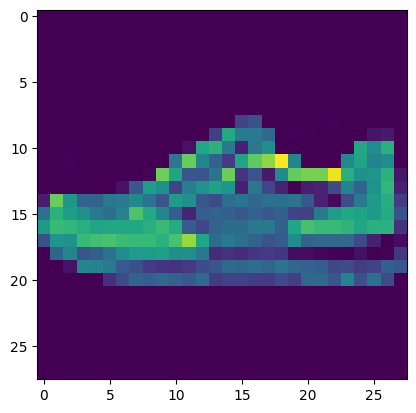

In [5]:
# plot a single sample

import matplotlib.pyplot as plt
plt.imshow(train_data[270])

In [ ]:
# create a small list so we can index onto our training label so they are human readable
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

len(class_names)

10

In [ ]:
# plot an example imaghe and its label
index = 27
plt.imshow(train_data[index],cmap=plt.cm.binary)
plt.title(class_names[train_label[index]])

In [ ]:
# plot multiple random images of fdashion mnist

import random
plt.figure(figsize=(7,7))
for i in range(6):
  ax=plt.subplot(3,3,i+1)
  rand_index = random.choice(range(len(train_data)))
  plt.imshow(train_data[rand_index],cmap=plt.cm.binary)
  plt.title(class_names[train_label[rand_index]])
  plt.axis(False)

## Building a multiclass classification model

for our multiclass classification model we can use a similar architecture to our binary classifies, however we're going to have to tweak a few things:
* input shape = 28 X 28 (the shape of an image)
* output shape (10 one per calss of clothing)
* loss function = tf.keras.losses.CategoricalCrossentropy()
* output layer activation = softmax (not sigmoid)

In [ ]:
import tensorflow as tf

# set seed
tf.random.set_seed(42)

# making our model

model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
     tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy', # Changed to sparse_categorical_crossentropy for integer labels
              optimizer=tf.keras.optimizers.Adam(),
                metrics=['accuracy'])

model.fit(train_data,train_label,epochs=20)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.7469 - loss: 1.0989
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8233 - loss: 0.4980
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8409 - loss: 0.4407
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8498 - loss: 0.4148
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8564 - loss: 0.3933
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8644 - loss: 0.3719
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8674 - loss: 0.3628
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8720 - loss: 0.3494
Epoch 9/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8763 - loss: 0.3416
Epoch 10/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8808 - loss: 0.3285
Epoch 11/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8831 - loss: 0.3234
Epoch 12/20
1875/1875 ━━━━━━━

In [ ]:
print('Evaluating the model on the test data:')
loss, accuracy = model.evaluate(test_data, test_label)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy*100:.2f}%")

Evaluating the model on the test data:
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8600 - loss: 0.4026
Test Loss: 0.4026
Test Accuracy: 86.00%


In [ ]:
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_7 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 207,680 (811.25 KB)

 Trainable params: 69,226 (270.41 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 138,454 (540.84 KB)

## model 2 without normalization

In [ ]:
import tensorflow as tf

# Set random seed for reproducibility
tf.random.set_seed(42)

# Create a more complex model (model_11)
model_11 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)), # Input layer
    tf.keras.layers.Dense(256, activation='relu'), # Increased neurons
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'), # Added another hidden layer
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax') # Output layer
])

# Compile the model
model_11.compile(loss='sparse_categorical_crossentropy',
                 optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), # Adjusted learning rate
                 metrics=['accuracy'])

# Create callbacks
# EarlyStopping to stop training when validation loss stops improving
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', # Monitor validation loss
    patience=5,         # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity
)

# LearningRateScheduler to adjust learning rate during training
def lr_schedule(epoch):
    # Gradually decrease learning rate
    if epoch < 10:
        return 0.001
    elif epoch < 20:
        return 0.0005
    else:
        return 0.0001

lr_scheduler = tf.keras.callbacks.LearningRateScheduler(lr_schedule)

# Fit the model with more epochs and callbacks
history_11 = model_11.fit(train_data, train_label,
                           epochs=50, # Increased epochs
                           validation_split=0.2, # Use a validation split to monitor overfitting
                           callbacks=[early_stopping, lr_scheduler])

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.6610 - loss: 1.2634 - val_accuracy: 0.7293 - val_loss: 0.7807 - learning_rate: 0.0010
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.7953 - loss: 0.6156 - val_accuracy: 0.8238 - val_loss: 0.5318 - learning_rate: 0.0010
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8302 - loss: 0.4797 - val_accuracy: 0.8441 - val_loss: 0.4614 - learning_rate: 0.0010
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8491 - loss: 0.4245 - val_accuracy: 0.8407 - val_loss: 0.4649 - learning_rate: 0.0010
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8571 - loss: 0.4024 - val_accuracy: 0.8528 - val_loss: 0.4321 - learning_rate: 0.0010
Epoch 6/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8648 - loss: 0.3773 - val_accuracy: 0.8529 - val_loss: 0.4274 - learning_rate: 0.0010
Epoch 7/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8709 - loss: 0

In [ ]:
print('Evaluating the improved model (model_11) on the test data:')
loss_11, accuracy_11 = model_11.evaluate(test_data, test_label)
print(f"Test Loss (model_11): {loss_11:.4f}")
print(f"Test Accuracy (model_11): {accuracy_11*100:.2f}%")

Evaluating the improved model (model_11) on the test data:
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8711 - loss: 0.3712
Test Loss (model_11): 0.3712
Test Accuracy (model_11): 87.11%


In [ ]:
# check the min and max value of the training data
train_data.min(),train_data.max()

(np.uint8(0), np.uint8(255))

## Neural Network tends to prefer to be scaled (normalization or standardization) mean they like to have data between 0 and 1

In [4]:
# we can get our training and testing data between 0 and 1 by dividing by the maximum

train_data_norm = train_data/255.0
test_data_norm = test_data/255.0

# check the min and max now
train_data_norm.min(),train_data_norm.max()

(np.float64(0.0), np.float64(1.0))

## finding the ideal learning rate

### Finding the Ideal Learning Rate for the CNN Model (with normalized data)

In [ ]:
import tensorflow as tf

# Set random seed for reproducibility
tf.random.set_seed(42)

# Re-create a fresh CNN model (model_cnn_lr_find) for learning rate finding
model_cnn_lr_find = tf.keras.Sequential([
    tf.keras.layers.Conv2D(filters=32, kernel_size=3, activation='relu', input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D(pool_size=2),
    tf.keras.layers.Conv2D(filters=64, kernel_size=3, activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Compile the model with an initial low learning rate
# The LearningRateScheduler will override this during training
model_cnn_lr_find.compile(loss='sparse_categorical_crossentropy',
                          optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                          metrics=['accuracy'])

# Create a LearningRateScheduler callback
# This callback will adjust the learning rate during training
lr_scheduler_cnn = tf.keras.callbacks.LearningRateScheduler(
    lambda epoch: 1e-4 * 10**(epoch / 20) # Start from 1e-4 and increase exponentially
)

print(f"Using reshaped normalized train_data shape for CNN: {train_data_norm_reshaped.shape}")

# Fit the model with the LearningRateScheduler
# Train for a limited number of epochs to observe loss across learning rates
history_cnn_lr = model_cnn_lr_find.fit(train_data_norm_reshaped,
                                       train_label,
                                       epochs=20, # Only 20 epochs for LR finding
                                       validation_split=0.2,
                                       callbacks=[lr_scheduler_cnn])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Using reshaped normalized train_data shape for CNN: (60000, 28, 28, 1)
Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7508 - loss: 0.7196 - val_accuracy: 0.8198 - val_loss: 0.5007 - learning_rate: 1.0000e-04
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8355 - loss: 0.4579 - val_accuracy: 0.8515 - val_loss: 0.4286 - learning_rate: 1.1220e-04
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8550 - loss: 0.4060 - val_accuracy: 0.8627 - val_loss: 0.3918 - learning_rate: 1.2589e-04
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8677 - loss: 0.3739 - val_accuracy: 0.8679 - val_loss: 0.3710 - learning_rate: 1.4125e-04
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8763 - loss: 0.3491 - val_accuracy: 0.8752 - val_loss: 0.3489 - learning_rate: 1.5849e-04
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8823 - loss: 0.3286 - val_accuracy: 0.8805 - val_loss: 0.3329 - learni

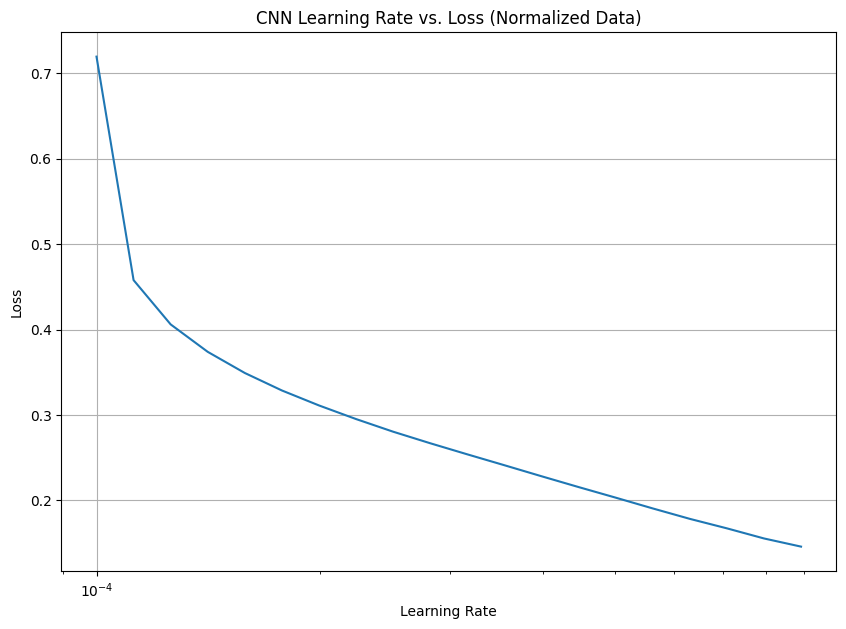

Look for the learning rate where the loss is decreasing rapidly or is at its lowest point.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get the learning rates used during training
lrs_cnn = 1e-4 * (10**(np.arange(len(history_cnn_lr.history['loss'])) / 20))

# Plot the learning rate vs. loss
plt.figure(figsize=(10, 7))
plt.semilogx(lrs_cnn, history_cnn_lr.history['loss'])
plt.xlabel("Learning Rate")
plt.ylabel("Loss")
plt.title("CNN Learning Rate vs. Loss (Normalized Data)")
plt.grid(True)
plt.show()

print("Look for the learning rate where the loss is decreasing rapidly or is at its lowest point.")

## evaluate our multicalss classification model

evaluate it performance

In [5]:
# Reshape data for CNN input (add a channel dimension)
train_data_norm_reshaped = train_data_norm.reshape(train_data_norm.shape[0], 28, 28, 1)
test_data_norm_reshaped = test_data_norm.reshape(test_data_norm.shape[0], 28, 28, 1)

print(f"Reshaped train_data_norm_reshaped shape: {train_data_norm_reshaped.shape}")
print(f"Reshaped test_data_norm_reshaped shape: {test_data_norm_reshaped.shape}")

import tensorflow as tf

# Set random seed for reproducibility
tf.random.set_seed(42)

# Define the CNN model with the optimal learning rate
model_cnn_optimized_lr = tf.keras.Sequential([
    tf.keras.layers.Conv2D(filters=32, kernel_size=3, activation='relu', input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D(pool_size=2),
    tf.keras.layers.Conv2D(filters=64, kernel_size=3, activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Compile the model with the optimal learning rate (0.0005)
model_cnn_optimized_lr.compile(loss='sparse_categorical_crossentropy',
                               optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
                               metrics=['accuracy'])

# Define EarlyStopping callback to prevent overfitting and save best weights
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5, # Stop if validation loss doesn't improve for 5 epochs
    restore_best_weights=True # Restore weights from the epoch with the best validation loss
)

print("Training model_cnn_optimized_lr with optimal learning rate...")
# Train the model
history_cnn_optimized_lr = model_cnn_optimized_lr.fit(
    train_data_norm_reshaped,
    train_label,
    epochs=30, # Train for a sufficient number of epochs, EarlyStopping will manage the actual number
    validation_split=0.2, # Use 20% of data for validation during training
    callbacks=[early_stopping]
)

print("Model training complete. Now evaluating on test data.")
loss, accuracy = model_cnn_optimized_lr.evaluate(test_data_norm_reshaped, test_label)
print(f"Test Loss for model_cnn_optimized_lr: {loss:.4f}")
print(f"Test Accuracy for model_cnn_optimized_lr: {accuracy*100:.2f}%")

Reshaped train_data_norm_reshaped shape: (60000, 28, 28, 1)
Reshaped test_data_norm_reshaped shape: (10000, 28, 28, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training model_cnn_optimized_lr with optimal learning rate...
Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8060 - loss: 0.5309 - val_accuracy: 0.8618 - val_loss: 0.3887
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8738 - loss: 0.3517 - val_accuracy: 0.8842 - val_loss: 0.3229
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8904 - loss: 0.3024 - val_accuracy: 0.8932 - val_loss: 0.2939
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9003 - loss: 0.2701 - val_accuracy: 0.8996 - val_loss: 0.2769
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9097 - loss: 0.2448 - val_accuracy: 0.9020 - val_loss: 0.2696
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9171 - loss: 0.2229 - val_accuracy: 0.9042 - val_loss: 0.2642
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9250 - loss: 0.2031 - val_accuracy: 0.9068 - val_loss: 0.2604
Epoch 8/30
1500/1500 ━━━━━

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


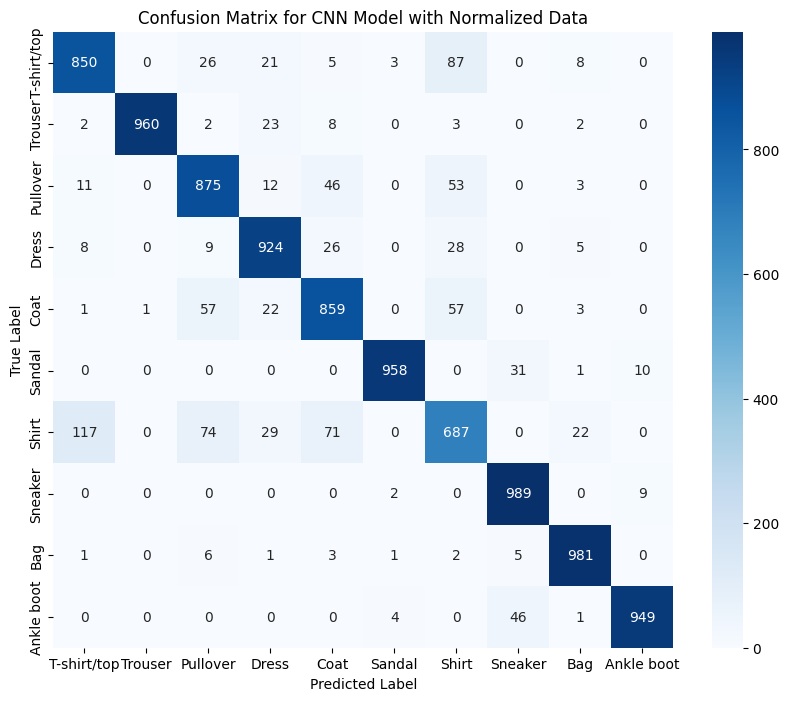

In [7]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Define class_names (re-added as it was not defined in the current scope)
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

# Make predictions on the test data using the trained model
y_pred_probabilities = model_cnn_optimized_lr.predict(test_data_norm_reshaped)
y_preds_classes = np.argmax(y_pred_probabilities, axis=1)

# Create the confusion matrix
cm = confusion_matrix(test_label, y_preds_classes)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for CNN Model with Normalized Data')
plt.show()

In [8]:
import random
import matplotlib.pyplot as plt
import numpy as np

def plot_Random_image(model, images, true_labels, classes):
  """
  Pick a random image, plot it, and display its real and predicted labels.
  """

  # Set up random integer
  i = random.randint(0, len(images) - 1)

  # Get the target image and its true label
  target_image = images[i]
  true_label = true_labels[i]

  # Reshape the image for model prediction (assuming it's a single channel image like Fashion MNIST)
  # The model expects a batch of images, so we add a batch dimension
  # and a channel dimension if it's not already there (e.g., (28, 28) -> (1, 28, 28, 1))
  if target_image.ndim == 2:
      # Add batch and channel dimensions
      reshaped_image = target_image[np.newaxis, ..., np.newaxis]
  elif target_image.ndim == 3 and target_image.shape[-1] == 1: # Already (H, W, 1)
      # Add batch dimension
      reshaped_image = target_image[np.newaxis, ...]
  else:
      # Assume it's already in a suitable shape, e.g., (1, 28, 28, 1)
      reshaped_image = target_image

  # Make predictions
  pred_probs = model.predict(reshaped_image)
  predicted_label_index = np.argmax(pred_probs)
  predicted_label = classes[predicted_label_index]

  # Plot the image
  plt.imshow(target_image, cmap=plt.cm.binary)
  color = "green" if predicted_label_index == true_label else "red"
  plt.title(f"True: {classes[true_label]} | Pred: {predicted_label}", color=color)
  plt.axis(False)
  plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


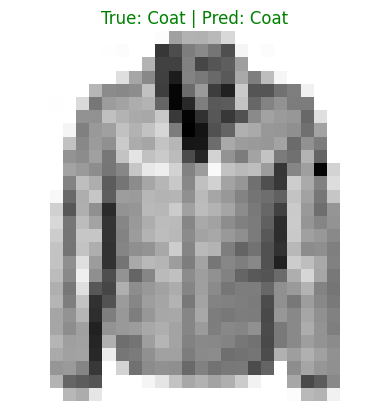

In [15]:
plot_Random_image(model=model_cnn_optimized_lr,
                  images=test_data_norm,
                  true_labels=test_label,
                  classes=class_names)

# what pattern is our model learning

In [17]:
# find the layers of our most recent model

model_cnn_optimized_lr.layers

[<Conv2D name=conv2d, built=True>,
 <MaxPooling2D name=max_pooling2d, built=True>,
 <Conv2D name=conv2d_1, built=True>,
 <MaxPooling2D name=max_pooling2d_1, built=True>,
 <Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dense name=dense_1, built=True>]

In [20]:
# extract a particular layer
model_cnn_optimized_lr.layers[1]

<MaxPooling2D name=max_pooling2d, built=True>

In [23]:
# get the patterns (weights and biases) of the first Conv2D layer (layer 0)

weights, biases = model_cnn_optimized_lr.layers[0].get_weights()

print(f"Weights shape: {weights.shape}")
print(f"Biases shape: {biases.shape}")

display(f"Weights (first filter):\n{weights[:, :, :, 0]}")
display(f"Biases (first 10):\n{biases[:10]}")

Weights shape: (3, 3, 1, 32)
Biases shape: (32,)


'Weights (first filter):\n[[[ 0.11039244]\n  [ 0.07173944]\n  [-0.19153772]]\n\n [[ 0.06837976]\n  [ 0.03344548]\n  [ 0.03700672]]\n\n [[ 0.03716598]\n  [-0.19078101]\n  [ 0.07188278]]]'

'Biases (first 10):\n[-3.2829054e-02  1.2828983e-01 -9.0999046e-04  7.0226535e-02\n  1.8239096e-01 -6.8771199e-04  5.8524269e-03 -1.1171783e-04\n -7.7147353e-03 -2.7884956e-02]'

In [24]:
biases,biases.shape

(array([-3.2829054e-02,  1.2828983e-01, -9.0999046e-04,  7.0226535e-02,
         1.8239096e-01, -6.8771199e-04,  5.8524269e-03, -1.1171783e-04,
        -7.7147353e-03, -2.7884956e-02, -1.3383563e-03,  7.9393312e-03,
        -5.1116785e-03, -8.2642008e-03, -7.5158193e-03, -4.0941570e-02,
         1.8911774e-01,  2.2481685e-03, -1.6676224e-03, -5.5381339e-02,
        -2.2971921e-02,  1.3332368e-03,  5.8767293e-03, -1.9879688e-03,
        -1.3101056e-02, -1.1454487e-02, -1.1312174e-02,  4.1350370e-04,
         6.4524496e-03, -1.4007034e-03, -3.8158258e-03, -8.0115953e-03],
       dtype=float32),
 (32,))

In [25]:
print('Summary of the CNN model with optimized learning rate:')
model_cnn_optimized_lr.summary()

Summary of the CNN model with optimized learning rate:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,104 (2.58 MB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 450,070 (1.72 MB)